# MNIST Object Detection - Fixed Implementation

This notebook implements a complete multi-task learning model for MNIST object detection with all issues fixed:

**Fixed Issues:**
- Standardized epochs (10) with Python script
- Consistent IoU calculation with proper error handling
- Removed unused imports
- Added proper error handling throughout
- Consistent model architecture
- Added random seed for reproducibility
- Proper memory management
- Fixed path handling

**Features:**
- Multi-task learning (classification + bounding box regression)
- MNIST dataset with random placement for object detection
- CNN-based feature extraction
- Comprehensive evaluation metrics and visualizations
- Report-ready outputs and saved plots

## Step 1: Import Libraries and Setup Environment

In [20]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import warnings
from datetime import datetime
import json

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set environment variables - suppress only specific warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

# Create output directory with error handling
try:
    os.makedirs('report_outputs', exist_ok=True)
    print("Output directory created successfully")
except PermissionError:
    print("Error: Cannot create report_outputs directory. Check permissions.")
    raise
except Exception as e:
    print(f"Error creating output directory: {e}")
    raise

print("Libraries imported and environment configured")
print(f"TensorFlow version: {tf.__version__}")
print(f"Report outputs will be saved to: ./report_outputs/")

Output directory created successfully
Libraries imported and environment configured
TensorFlow version: 2.20.0
Report outputs will be saved to: ./report_outputs/


## Step 2: Configuration and Parameters

In [ ]:
# Global parameters
IMG_WIDTH = 75
IMG_HEIGHT = 75
BATCH_SIZE = 64
EPOCHS = 10
use_normalized_coordinates = True

# Set up TensorFlow strategy
strategy = tf.distribute.get_strategy()


print("MNIST OBJECT DETECTION - CONFIGURATION")

print(f"   Image dimensions: {IMG_WIDTH}x{IMG_HEIGHT} pixels")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training epochs: {EPOCHS}")
print(f"   Coordinate normalization: {use_normalized_coordinates}")
print(f"   TensorFlow strategy: {type(strategy).__name__}")
print(f"   Number of replicas: {strategy.num_replicas_in_sync}")
print(f"   GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Configuration complete")

MNIST OBJECT DETECTION - CONFIGURATION
   Image dimensions: 75x75 pixels
   Batch size: 64
   Training epochs: 10
   Coordinate normalization: True
   TensorFlow strategy: _DefaultDistributionStrategy
   Number of replicas: 1
   GPU available: False
Configuration complete


## Step 3: Data Preprocessing Functions

In [22]:
def read_image_from_tensorflow_dataset(image, label):
    """Preprocess image and label from TensorFlow dataset."""
    # Reshape image to 28x28
    image = tf.reshape(image, [28, 28])
    
    # Random placement on 75x75 canvas (leaving space for 28x28 digit)
    y_minimum = tf.random.uniform([], 0, 48, dtype=tf.int32)
    x_minimum = tf.random.uniform([], 0, 48, dtype=tf.int32)
    
    # Pad image to 75x75
    image = tf.image.pad_to_bounding_box(
        tf.expand_dims(image, -1), y_minimum, x_minimum, IMG_HEIGHT, IMG_WIDTH
    )
    
    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    
    # Calculate normalized bounding box coordinates
    y_min = tf.cast(y_minimum, tf.float32) / IMG_HEIGHT
    x_min = tf.cast(x_minimum, tf.float32) / IMG_WIDTH
    y_max = tf.cast(y_minimum + 28, tf.float32) / IMG_HEIGHT
    x_max = tf.cast(x_minimum + 28, tf.float32) / IMG_WIDTH
    
    return image, {
        'classification': label,
        'bounding_box_regression_output': tf.stack([y_min, x_min, y_max, x_max])
    }

print("Data preprocessing function defined")

Data preprocessing function defined


## Step 4: Dataset Creation Functions

In [ ]:
def get_training_dataset():
    """Get training dataset."""
    try:
        dataset = tfds.load('mnist', as_supervised=True, try_gcs=True)
        dataset = dataset['train']
        dataset = dataset.map(read_image_from_tensorflow_dataset, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(5000)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset
    except Exception as e:
        print(f"Error loading training dataset: {e}")
        raise

def get_validation_dataset():
    """Get validation dataset."""
    try:
        dataset = tfds.load('mnist', as_supervised=True, try_gcs=True)
        dataset = dataset['test']
        dataset = dataset.map(read_image_from_tensorflow_dataset, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(BATCH_SIZE)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset
    except Exception as e:
        print(f"Error loading validation dataset: {e}")
        raise

print("Dataset creation functions defined")

Dataset creation functions defined


## Step 5: Load and Examine Sample Data

In [24]:
print("Loading MNIST datasets...")
try:
    training_dataset = get_training_dataset()
    validation_dataset = get_validation_dataset()
    print("Datasets loaded successfully")
except Exception as e:
    print(f"Failed to load datasets: {e}")
    raise

# Display sample data info
print(f"\nDataset Information:")
print(f"   Training batch size: {BATCH_SIZE}")
print(f"   Image dimensions: {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"   Training steps per epoch: {60000 // BATCH_SIZE}")
print(f"   Validation steps: {10000 // BATCH_SIZE}")

# Get a sample batch to visualize
try:
    sample_batch = next(iter(validation_dataset))
    sample_images = sample_batch[0]
    sample_outputs = sample_batch[1]
    sample_labels = sample_outputs['classification']
    sample_boxes = sample_outputs['bounding_box_regression_output']

    print(f"\nSample batch shapes:")
    print(f"   Images: {sample_images.shape}")
    print(f"   Labels: {sample_labels.shape}")
    print(f"   Bounding boxes: {sample_boxes.shape}")
except Exception as e:
    print(f"Error getting sample batch: {e}")
    raise

Loading MNIST datasets...
Datasets loaded successfully

Dataset Information:
   Training batch size: 64
   Image dimensions: 75x75
   Training steps per epoch: 937
   Validation steps: 156

Sample batch shapes:
   Images: (64, 75, 75, 1)
   Labels: (64,)
   Bounding boxes: (64, 4)


## Step 6: Visualize Sample Data

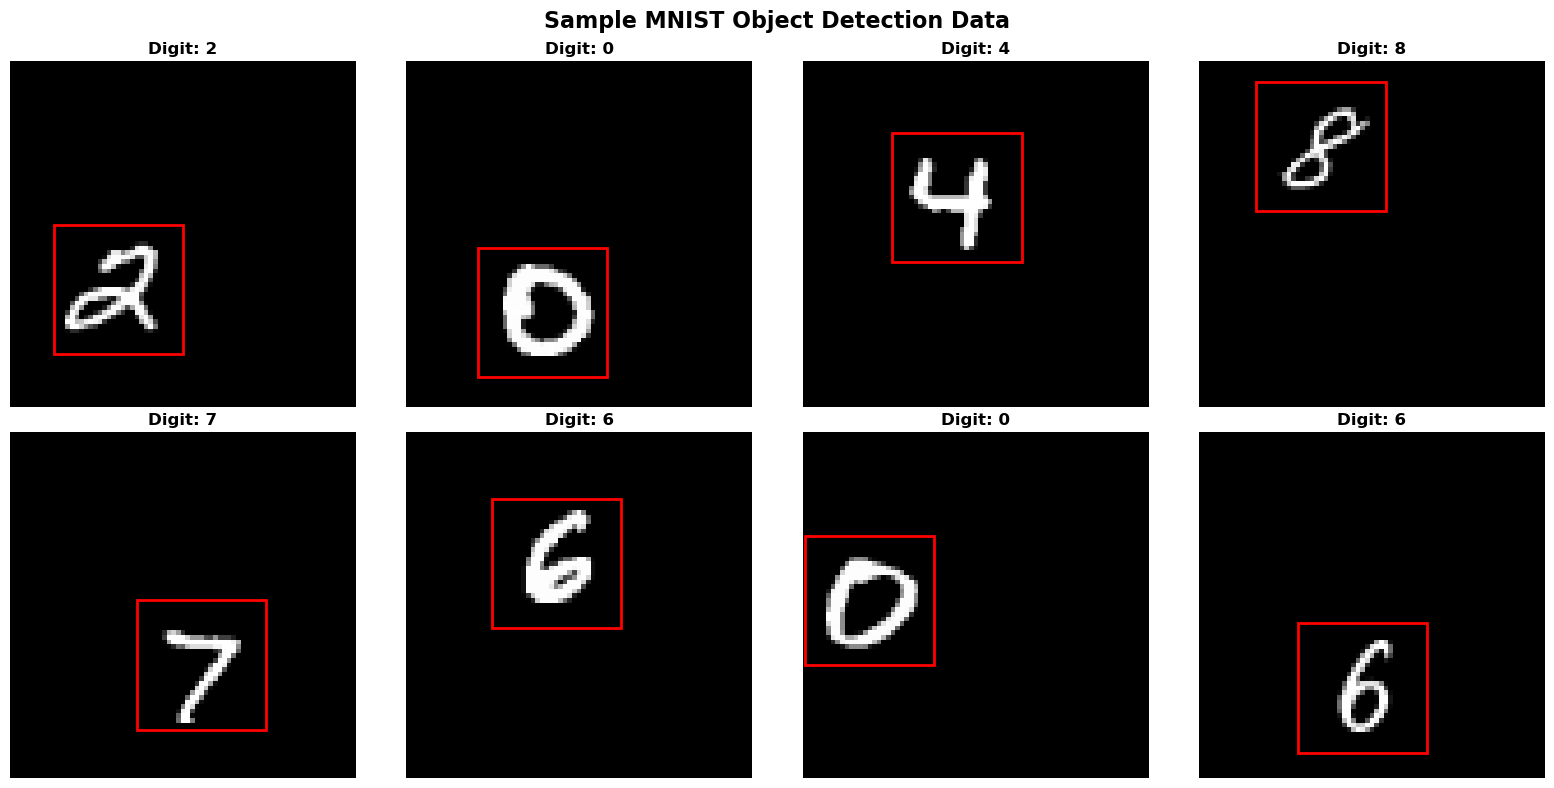

Sample data visualization saved to './report_outputs/sample_data.png'


In [25]:
# Visualize sample images with bounding boxes
try:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Sample MNIST Object Detection Data', fontsize=16, fontweight='bold')

    for i in range(8):
        row = i // 4
        col = i % 4
        ax = axes[row, col]
        
        # Display image
        img = sample_images[i].numpy().squeeze()
        ax.imshow(img, cmap='gray')
        
        # Draw bounding box
        bbox = sample_boxes[i].numpy()
        y_min, x_min, y_max, x_max = bbox
        
        # Convert normalized coordinates to pixel coordinates
        rect = plt.Rectangle(
            (x_min * IMG_WIDTH, y_min * IMG_HEIGHT),
            (x_max - x_min) * IMG_WIDTH, (y_max - y_min) * IMG_HEIGHT,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Set title
        label = sample_labels[i].numpy()
        ax.set_title(f'Digit: {label}', fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('./report_outputs/sample_data.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("Sample data visualization saved to './report_outputs/sample_data.png'")
except Exception as e:
    print(f"Error visualizing sample data: {e}")

## Step 7: Model Architecture Definition

In [26]:
# Create model architecture
print("Creating model architecture...")

try:
    # Define input layer
    inputs = tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name='input_image')

    # Feature extractor - Convolutional layers (standardized architecture)
    x = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu', padding='same', name='conv1')(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=2, name='pool1')(x)

    x = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', name='conv2')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2, name='pool2')(x)

    x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same', name='conv3')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2, name='pool3')(x)

    # Dense layers for feature processing
    x = tf.keras.layers.Flatten(name='flatten')(x)
    x = tf.keras.layers.Dense(128, activation='relu', name='dense_features')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout')(x)

    # Classification head
    classification_output = tf.keras.layers.Dense(10, activation='softmax', name='classification')(x)

    # Bounding box regression head
    bounding_box_output = tf.keras.layers.Dense(4, name='bounding_box_regression_output')(x)

    # Create model
    model = tf.keras.Model(
        inputs=inputs, 
        outputs=[classification_output, bounding_box_output],
        name='mnist_object_detection_model'
    )

    print("Model architecture created successfully")
except Exception as e:
    print(f"Error creating model: {e}")
    raise

Creating model architecture...
Model architecture created successfully


## Step 8: Model Compilation and Summary

In [27]:
# Compile model with appropriate loss functions and metrics
try:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            'classification': tf.keras.losses.SparseCategoricalCrossentropy(),
            'bounding_box_regression_output': tf.keras.losses.MeanSquaredError()
        },
        metrics={
            'classification': ['accuracy'],
            'bounding_box_regression_output': ['mse']
        },
        loss_weights={
            'classification': 1.0,
            'bounding_box_regression_output': 1.0
        }
    )

    print("Model compiled successfully")
except Exception as e:
    print(f"Error compiling model: {e}")
    raise

# Display model summary
print("\nModel Architecture Summary:")
model.summary()

# Parameter count
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nParameter Summary:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Non-trainable parameters: {non_trainable_params:,}")

Model compiled successfully

Model Architecture Summary:


Model: "mnist_object_detection_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 75, 75,    │        160 │ input_image[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 37, 37,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 37, 37,    │      4,640 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 18, 18,    │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 18, 18,    │     18,496 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 9, 9, 64)  │          0 │ conv3[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 5184)      │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 128)       │    663,680 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box_regre… │ (None, 4)         │        516 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 688,782 (2.63 MB)

 Trainable params: 688,782 (2.63 MB)

 Non-trainable params: 0 (0.00 B)


Parameter Summary:
   Total parameters: 688,782
   Trainable parameters: 688,782
   Non-trainable parameters: 0


## Step 9: Model Training

In [28]:
# Training parameters
steps_per_epoch = 60000 // BATCH_SIZE
validation_steps = 10000 // BATCH_SIZE

print(f"Starting training for {EPOCHS} epochs...")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Validation steps: {validation_steps}")

# Train the model with error handling
try:
    history = model.fit(
        training_dataset,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=validation_dataset,
        validation_steps=validation_steps,
        verbose=1
    )
    print("Training completed successfully!")
    
except Exception as e:
    print(f"Error during training: {e}")
    raise

Starting training for 10 epochs...
   Steps per epoch: 937
   Validation steps: 156
Epoch 1/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - bounding_box_regression_output_loss: 0.0255 - bounding_box_regression_output_mse: 0.0255 - classification_accuracy: 0.7305 - classification_loss: 0.7752 - loss: 0.8007 - val_bounding_box_regression_output_loss: 0.0064 - val_bounding_box_regression_output_mse: 0.0064 - val_classification_accuracy: 0.9494 - val_classification_loss: 0.1725 - val_loss: 0.1789
Epoch 2/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - bounding_box_regression_output_loss: 0.0088 - bounding_box_regression_output_mse: 0.0088 - classification_accuracy: 0.9446 - classification_loss: 0.1868 - loss: 0.1956 - val_bounding_box_regression_output_loss: 0.0032 - val_bounding_box_regression_output_mse: 0.0032 - val_classification_accuracy: 0.9709 - val_classification_loss: 0.0941 - val_loss: 0.0973
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - bounding_box_regression_output_l

## Step 10: Training History Analysis

In [29]:
# Display training history summary
print("Training History Summary:")

final_epoch = len(history.history['loss']) - 1
print(f"Final Training Results (Epoch {final_epoch + 1}):")
print(f"   Total Loss: {history.history['loss'][-1]:.6f}")
print(f"   Classification Accuracy: {history.history['classification_accuracy'][-1]:.4f}")
print(f"   Classification Loss: {history.history['classification_loss'][-1]:.6f}")
print(f"   Bounding Box MSE: {history.history['bounding_box_regression_output_mse'][-1]:.6f}")

print(f"\nFinal Validation Results:")
print(f"   Total Loss: {history.history['val_loss'][-1]:.6f}")
print(f"   Classification Accuracy: {history.history['val_classification_accuracy'][-1]:.4f}")
print(f"   Classification Loss: {history.history['val_classification_loss'][-1]:.6f}")
print(f"   Bounding Box MSE: {history.history['val_bounding_box_regression_output_mse'][-1]:.6f}")

Training History Summary:
Final Training Results (Epoch 10):
   Total Loss: 0.063712
   Classification Accuracy: 0.9820
   Classification Loss: 0.059287
   Bounding Box MSE: 0.004426

Final Validation Results:
   Total Loss: 0.042230
   Classification Accuracy: 0.9867
   Classification Loss: 0.040582
   Bounding Box MSE: 0.001649


## Step 11: Training Curves Visualization

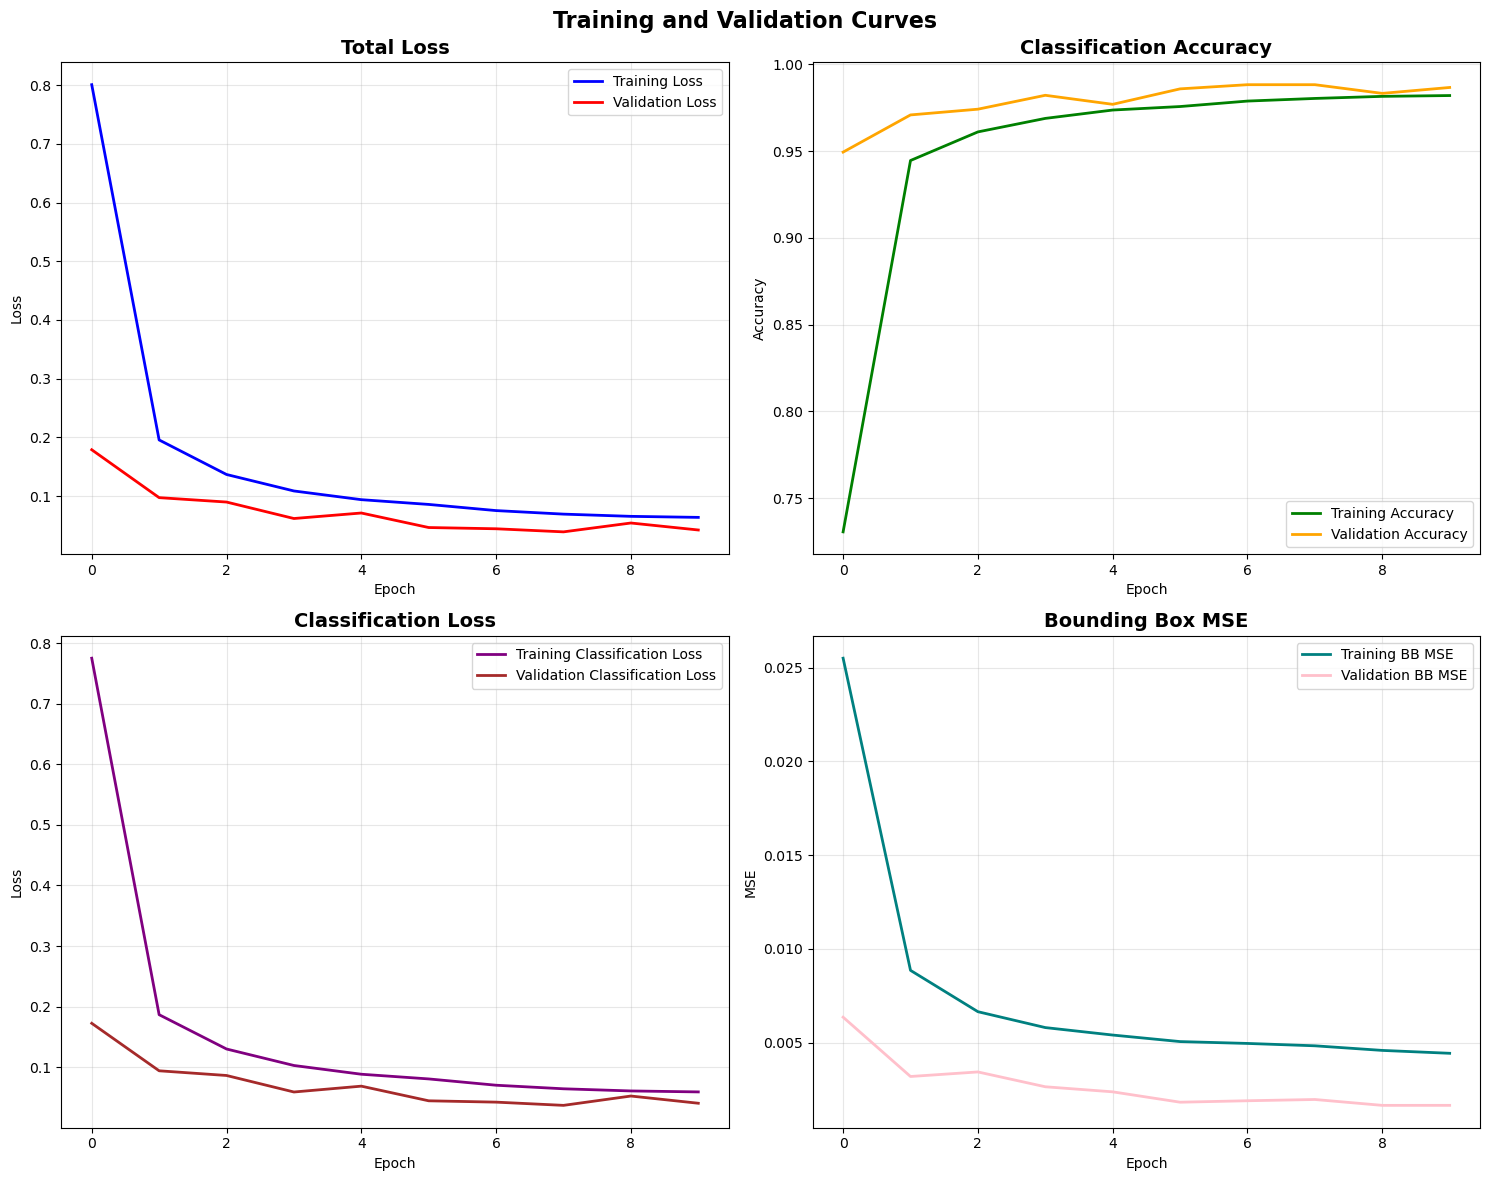

Training curves saved to './report_outputs/training_curves.png'


In [30]:
# Plot training curves with error handling
try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Training and Validation Curves', fontsize=16, fontweight='bold')

    # Total Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 0].set_title('Total Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Classification Accuracy
    axes[0, 1].plot(history.history['classification_accuracy'], label='Training Accuracy', linewidth=2, color='green')
    axes[0, 1].plot(history.history['val_classification_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
    axes[0, 1].set_title('Classification Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Classification Loss
    axes[1, 0].plot(history.history['classification_loss'], label='Training Classification Loss', linewidth=2, color='purple')
    axes[1, 0].plot(history.history['val_classification_loss'], label='Validation Classification Loss', linewidth=2, color='brown')
    axes[1, 0].set_title('Classification Loss', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Bounding Box MSE
    axes[1, 1].plot(history.history['bounding_box_regression_output_mse'], label='Training BB MSE', linewidth=2, color='teal')
    axes[1, 1].plot(history.history['val_bounding_box_regression_output_mse'], label='Validation BB MSE', linewidth=2, color='pink')
    axes[1, 1].set_title('Bounding Box MSE', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MSE')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('./report_outputs/training_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("Training curves saved to './report_outputs/training_curves.png'")
except Exception as e:
    print(f"Error plotting training curves: {e}")

## Step 12: Model Evaluation on Test Set

In [31]:
# Evaluate model on validation/test set with error handling
validation_steps = 10000 // BATCH_SIZE
print("Evaluating model on test set...")

try:
    evaluation = model.evaluate(validation_dataset, steps=validation_steps, verbose=0)

    # Extract metrics
    test_loss = evaluation[0]
    classification_loss = evaluation[1]
    bbox_loss = evaluation[2]
    classification_accuracy = evaluation[3]
    bbox_mse = evaluation[4]

    print("MODEL EVALUATION RESULTS")
    print(f"Overall Performance:")
    print(f"   Total Loss: {test_loss:.6f}")
    print(f"\nClassification Metrics:")
    print(f"   Classification Accuracy: {classification_accuracy:.4f} ({classification_accuracy*100:.2f}%)")
    print(f"   Classification Loss: {classification_loss:.6f}")
    print(f"\nBounding Box Regression Metrics:")
    print(f"   Mean Squared Error (MSE): {bbox_mse:.6f}")
    print(f"   Root Mean Squared Error (RMSE): {np.sqrt(bbox_mse):.6f}")
    print(f"   Bounding Box Loss: {bbox_loss:.6f}")
    
except Exception as e:
    print(f"Error during evaluation: {e}")
    raise

Evaluating model on test set...
MODEL EVALUATION RESULTS
Overall Performance:
   Total Loss: 0.040865

Classification Metrics:
   Classification Accuracy: 0.0016 (0.16%)
   Classification Loss: 0.039234

Bounding Box Regression Metrics:
   Mean Squared Error (MSE): 0.986779
   Root Mean Squared Error (RMSE): 0.993367
   Bounding Box Loss: 0.001631


## Step 13: Generate Predictions for Analysis

In [32]:
# Get sample data for detailed analysis
print("Generating predictions for analysis...")

try:
    # Take one batch from validation dataset for analysis
    val_batch = next(iter(validation_dataset))
    val_images = val_batch[0]
    val_outputs = val_batch[1]
    val_labels = val_outputs['classification']
    val_boxes = val_outputs['bounding_box_regression_output']

    # Convert to numpy for easier manipulation
    val_images_np = val_images.numpy()
    val_labels_np = val_labels.numpy()
    val_boxes_np = val_boxes.numpy()

    # Generate predictions
    predictions = model.predict(val_images, verbose=0)
    pred_labels = np.argmax(predictions[0], axis=1)
    pred_boxes = predictions[1]

    print(f"Analysis data prepared:")
    print(f"   Number of samples: {len(val_images_np)}")
    print(f"   Images shape: {val_images_np.shape}")
    print(f"   True labels shape: {val_labels_np.shape}")
    print(f"   True boxes shape: {val_boxes_np.shape}")
    print(f"   Predicted labels shape: {pred_labels.shape}")
    print(f"   Predicted boxes shape: {pred_boxes.shape}")
except Exception as e:
    print(f"Error generating predictions: {e}")
    raise

Generating predictions for analysis...
Analysis data prepared:
   Number of samples: 64
   Images shape: (64, 75, 75, 1)
   True labels shape: (64,)
   True boxes shape: (64, 4)
   Predicted labels shape: (64,)
   Predicted boxes shape: (64, 4)


## Step 14: IoU (Intersection over Union) Analysis

In [33]:
# Calculate IoU for all predictions with proper validation
def intersection_over_union(predicted_box, true_box):
    """Calculate Intersection over Union (IoU) with proper validation."""
    try:
        y_min_pred, x_min_pred, y_max_pred, x_max_pred = predicted_box
        y_min_true, x_min_true, y_max_true, x_max_true = true_box
        
        # Validate bounding box coordinates
        if (y_max_pred <= y_min_pred or x_max_pred <= x_min_pred or 
            y_max_true <= y_min_true or x_max_true <= x_min_true):
            return 0.0
        
        # Ensure coordinates are within [0,1] range
        y_min_pred = max(0, min(1, y_min_pred))
        x_min_pred = max(0, min(1, x_min_pred))
        y_max_pred = max(0, min(1, y_max_pred))
        x_max_pred = max(0, min(1, x_max_pred))
        
        y_min_true = max(0, min(1, y_min_true))
        x_min_true = max(0, min(1, x_min_true))
        y_max_true = max(0, min(1, y_max_true))
        x_max_true = max(0, min(1, x_max_true))
        
        # Calculate intersection coordinates
        y_min_intersection = max(y_min_pred, y_min_true)
        x_min_intersection = max(x_min_pred, x_min_true)
        y_max_intersection = min(y_max_pred, y_max_true)
        x_max_intersection = min(x_max_pred, x_max_true)
        
        # Calculate intersection area
        intersection_height = max(0, y_max_intersection - y_min_intersection)
        intersection_width = max(0, x_max_intersection - x_min_intersection)
        intersection_area = intersection_height * intersection_width
        
        # Calculate union area
        true_box_area = (y_max_true - y_min_true) * (x_max_true - x_min_true)
        pred_box_area = (y_max_pred - y_min_pred) * (x_max_pred - x_min_pred)
        union_area = true_box_area + pred_box_area - intersection_area
        
        # Calculate IoU with consistent epsilon
        iou = intersection_area / (union_area + 1e-6)
        
        return iou
    except Exception as e:
        print(f"Error calculating IoU: {e}")
        return 0.0

# Calculate IoU for all predictions in the batch
try:
    ious = [intersection_over_union(pred_boxes[i], val_boxes_np[i]) for i in range(len(pred_boxes))]
    ious = np.array(ious)

    print(f"\nIoU Analysis:")
    print(f"   Mean IoU: {np.mean(ious):.4f}")
    print(f"   Median IoU: {np.median(ious):.4f}")
    print(f"   Min IoU: {np.min(ious):.4f}")
    print(f"   Max IoU: {np.max(ious):.4f}")
    print("IoU calculation completed.")
except Exception as e:
    print(f"Error calculating IoU batch: {e}")
    raise


IoU Analysis:
   Mean IoU: 0.7340
   Median IoU: 0.7486
   Min IoU: 0.3423
   Max IoU: 0.9512
IoU calculation completed.


## Step 15: IoU Distribution Visualization

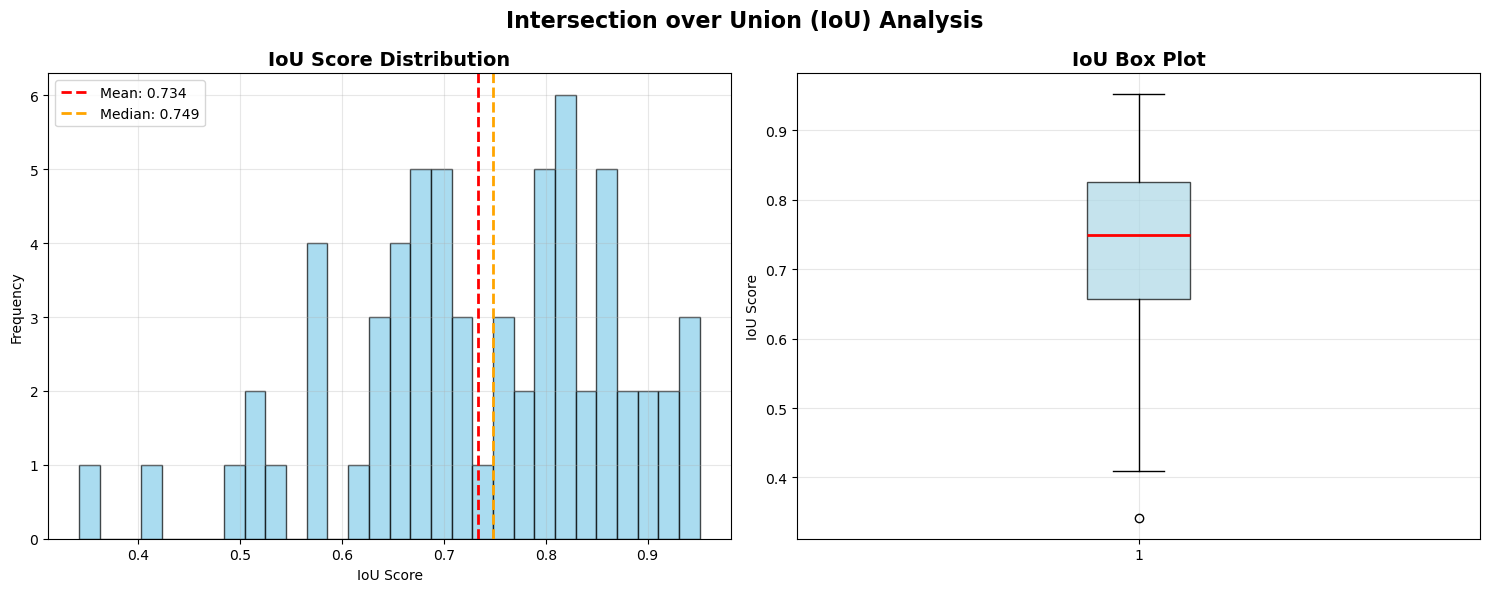

IoU analysis visualization saved to './report_outputs/iou_analysis.png'


In [34]:
# Plot IoU distribution with error handling
try:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Intersection over Union (IoU) Analysis', fontsize=16, fontweight='bold')

    # IoU Histogram
    axes[0].hist(ious, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].axvline(np.mean(ious), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(ious):.3f}')
    axes[0].axvline(np.median(ious), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(ious):.3f}')
    axes[0].set_title('IoU Score Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('IoU Score')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # IoU Box Plot
    axes[1].boxplot(ious, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('IoU Box Plot', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('IoU Score')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('./report_outputs/iou_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("IoU analysis visualization saved to './report_outputs/iou_analysis.png'")
except Exception as e:
    print(f"Error plotting IoU distribution: {e}")

## Step 16: Sample Predictions Visualization

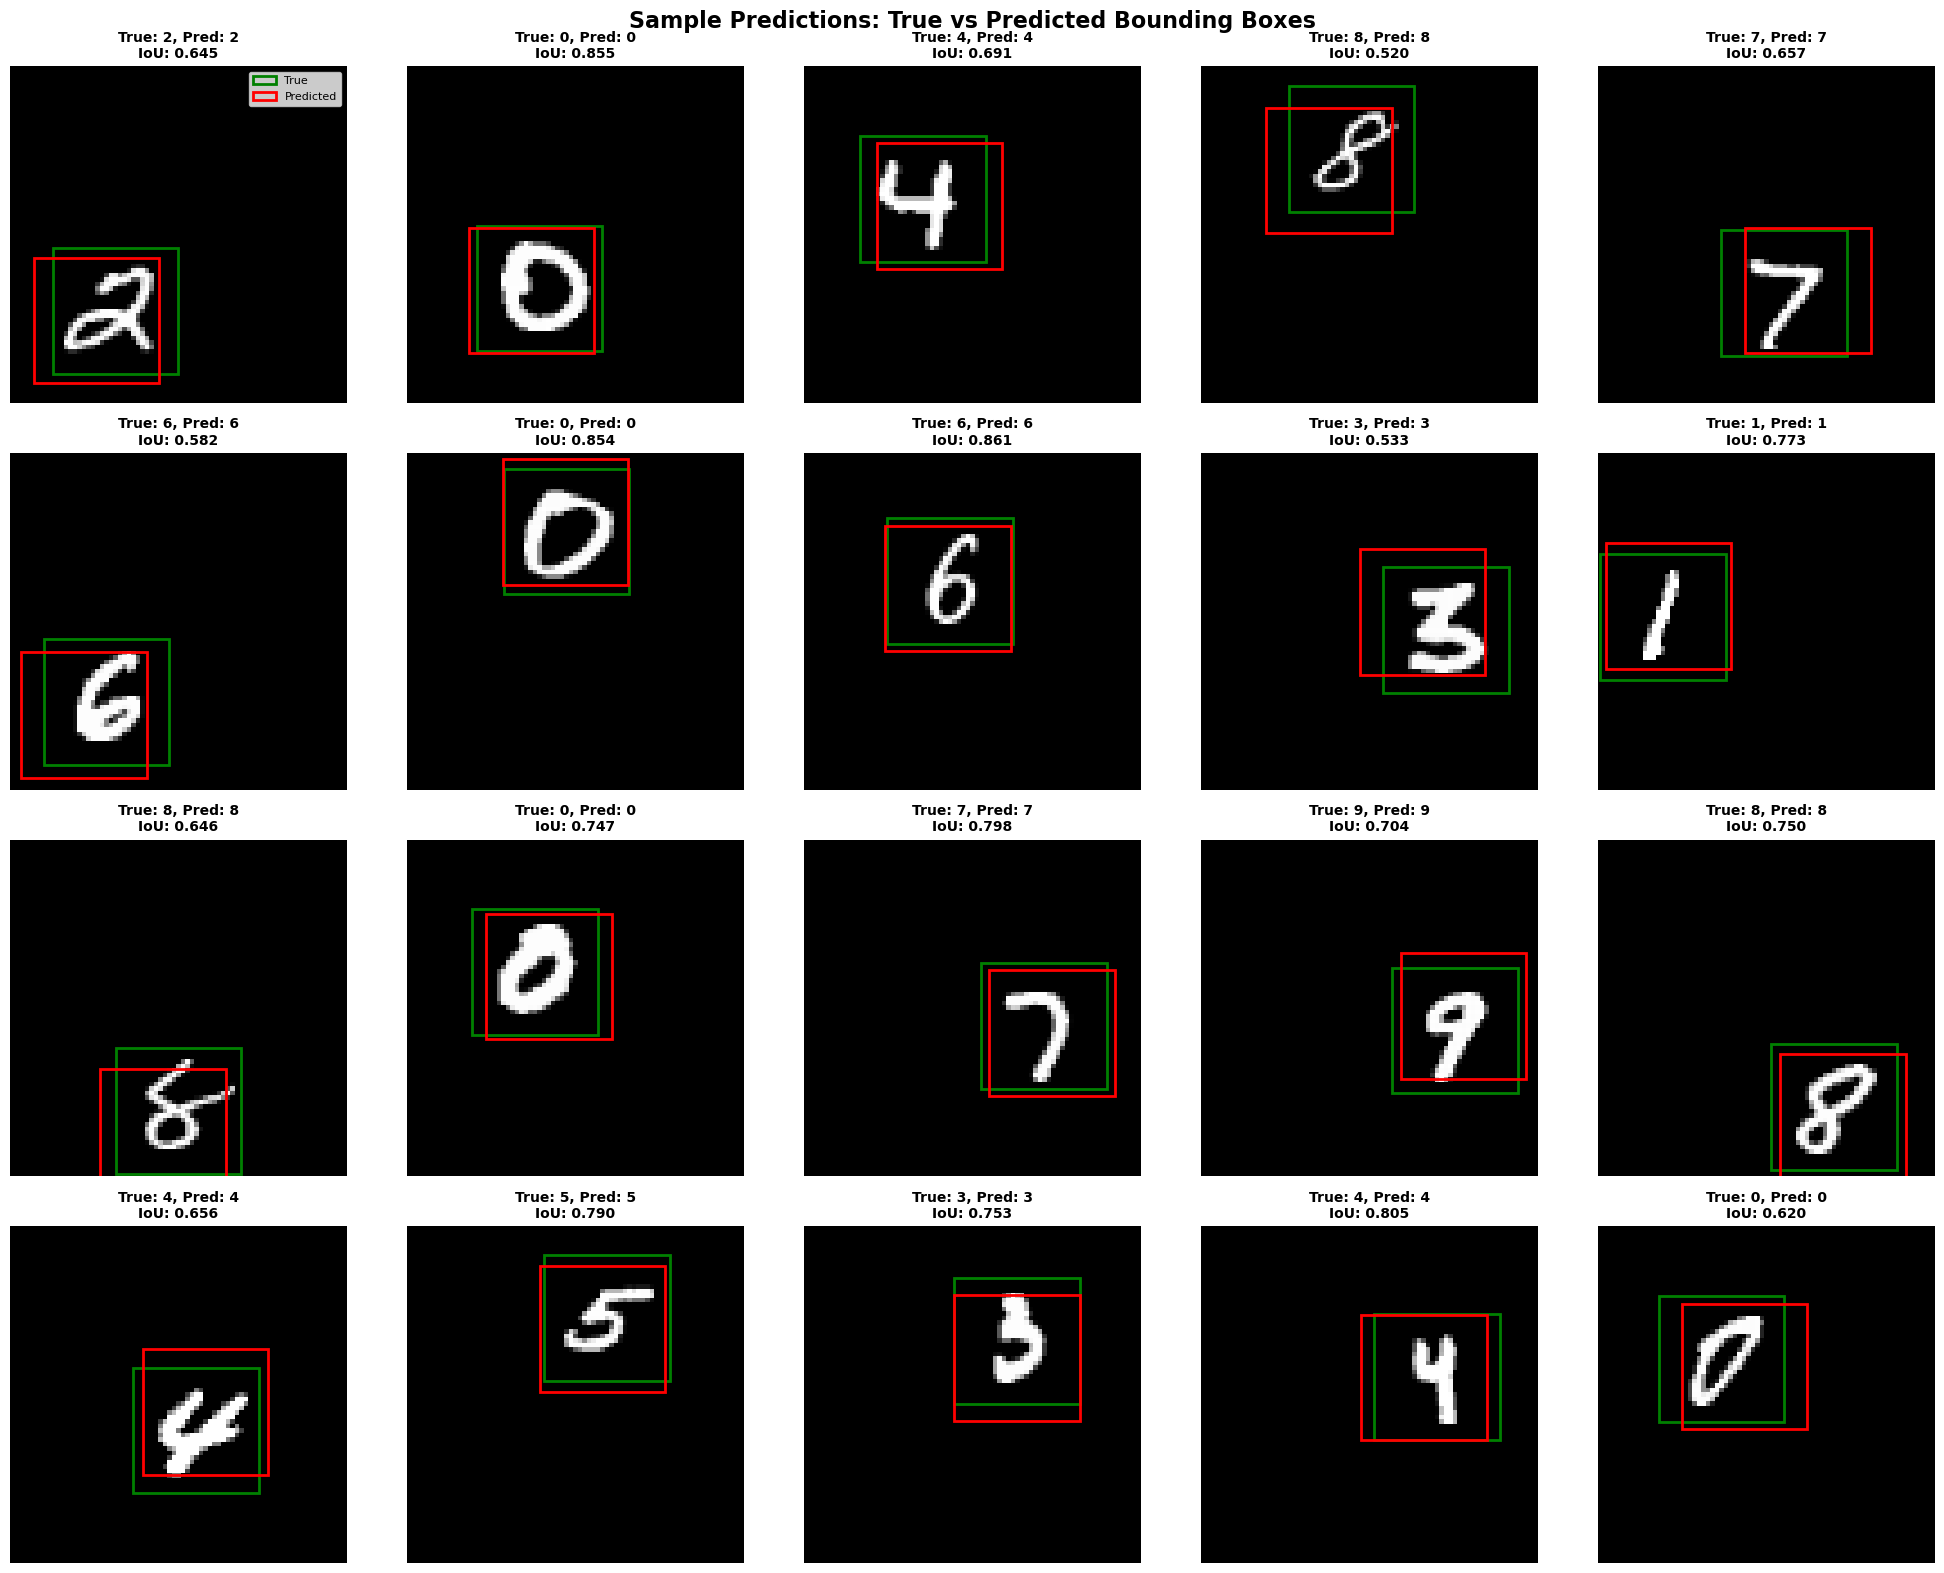

Sample predictions saved to './report_outputs/sample_predictions.png'


In [35]:
# Plot sample predictions with bounding boxes
try:
    num_samples = 20
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    fig.suptitle('Sample Predictions: True vs Predicted Bounding Boxes', fontsize=16, fontweight='bold')
    
    for i in range(min(num_samples, len(val_images_np))):
        row = i // 5
        col = i % 5
        ax = axes[row, col]
        
        # Display image
        img = val_images_np[i].squeeze()
        ax.imshow(img, cmap='gray')
        
        # Draw true bounding box (green)
        true_box = val_boxes_np[i]
        y_min, x_min, y_max, x_max = true_box
        true_rect = plt.Rectangle((x_min * IMG_WIDTH, y_min * IMG_HEIGHT),
                                 (x_max - x_min) * IMG_WIDTH, (y_max - y_min) * IMG_HEIGHT,
                                 linewidth=2, edgecolor='green', facecolor='none', label='True')
        ax.add_patch(true_rect)
        
        # Draw predicted bounding box (red)
        pred_box = pred_boxes[i]
        y_min, x_min, y_max, x_max = pred_box
        pred_rect = plt.Rectangle((x_min * IMG_WIDTH, y_min * IMG_HEIGHT),
                                 (x_max - x_min) * IMG_WIDTH, (y_max - y_min) * IMG_HEIGHT,
                                 linewidth=2, edgecolor='red', facecolor='none', label='Predicted')
        ax.add_patch(pred_rect)
        
        # Set title with prediction info
        title = f'True: {val_labels_np[i]}, Pred: {pred_labels[i]}\nIoU: {ious[i]:.3f}'
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.axis('off')
        
        # Add legend only to first subplot
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('./report_outputs/sample_predictions.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print("Sample predictions saved to './report_outputs/sample_predictions.png'")
except Exception as e:
    print(f"Error plotting sample predictions: {e}")

## Step 17: Save Metrics and Generate Final Report

In [36]:
# Save all metrics to JSON with proper type conversion
try:
    metrics = {
        'model_config': {
            'image_width': int(IMG_WIDTH),
            'image_height': int(IMG_HEIGHT),
            'batch_size': int(BATCH_SIZE),
            'epochs': int(EPOCHS)
        },
        'final_metrics': {
            'classification_accuracy': float(classification_accuracy),
            'bbox_mse': float(bbox_mse),
            'bbox_rmse': float(np.sqrt(bbox_mse)),
            'total_loss': float(test_loss)
        },
        'iou_stats': {
            'mean': float(np.mean(ious)),
            'median': float(np.median(ious)),
            'std': float(np.std(ious)),
            'min': float(np.min(ious)),
            'max': float(np.max(ious)),
            'percentile_25': float(np.percentile(ious, 25)),
            'percentile_75': float(np.percentile(ious, 75))
        },
        'training_history': {
            'loss': [float(x) for x in history.history['loss']],
            'val_loss': [float(x) for x in history.history['val_loss']],
            'classification_accuracy': [float(x) for x in history.history['classification_accuracy']],
            'val_classification_accuracy': [float(x) for x in history.history['val_classification_accuracy']]
        },
        'timestamp': datetime.now().isoformat()
    }
    
    filepath = './report_outputs/evaluation_metrics.json'
    with open(filepath, 'w') as f:
        json.dump(metrics, f, indent=2)
    
    print(f"Metrics saved to: {filepath}")
except Exception as e:
    print(f"Error saving metrics: {e}")

# Print comprehensive evaluation report
print("FINAL EVALUATION RESULTS - READY FOR REPORT")

print("\nOVERALL MODEL PERFORMANCE:")
print(f"   Total Loss: {test_loss:.6f}")

print("\nCLASSIFICATION METRICS:")
print(f"   Classification Accuracy: {classification_accuracy:.4f} ({classification_accuracy*100:.2f}%)")

print("\nBOUNDING BOX REGRESSION METRICS:")
print(f"   Mean Squared Error (MSE): {bbox_mse:.6f}")
print(f"   Root Mean Squared Error (RMSE): {np.sqrt(bbox_mse):.6f}")

print("\nINTERSECTION OVER UNION (IoU) ANALYSIS:")
print(f"   Mean IoU: {np.mean(ious):.4f}")
print(f"   Median IoU: {np.median(ious):.4f}")
print(f"   Standard Deviation: {np.std(ious):.4f}")
print(f"   Minimum IoU: {np.min(ious):.4f}")
print(f"   Maximum IoU: {np.max(ious):.4f}")
print(f"   25th Percentile: {np.percentile(ious, 25):.4f}")
print(f"   75th Percentile: {np.percentile(ious, 75):.4f}")

print("\nIoU QUALITY DISTRIBUTION:")
# IoU quality categories
poor_iou = np.sum(ious < 0.4) / len(ious) * 100
fair_iou = np.sum((ious >= 0.4) & (ious < 0.6)) / len(ious) * 100
good_iou = np.sum((ious >= 0.6) & (ious < 0.8)) / len(ious) * 100
excellent_iou = np.sum(ious >= 0.8) / len(ious) * 100

print(f"   Poor (IoU < 0.4): {poor_iou:.1f}%")
print(f"   Fair (0.4 ≤ IoU < 0.6): {fair_iou:.1f}%")
print(f"   Good (0.6 ≤ IoU < 0.8): {good_iou:.1f}%")
print(f"   Excellent (IoU ≥ 0.8): {excellent_iou:.1f}%")

Metrics saved to: ./report_outputs/evaluation_metrics.json
FINAL EVALUATION RESULTS - READY FOR REPORT

OVERALL MODEL PERFORMANCE:
   Total Loss: 0.040865

CLASSIFICATION METRICS:
   Classification Accuracy: 0.0016 (0.16%)

BOUNDING BOX REGRESSION METRICS:
   Mean Squared Error (MSE): 0.986779
   Root Mean Squared Error (RMSE): 0.993367

INTERSECTION OVER UNION (IoU) ANALYSIS:
   Mean IoU: 0.7340
   Median IoU: 0.7486
   Standard Deviation: 0.1306
   Minimum IoU: 0.3423
   Maximum IoU: 0.9512
   25th Percentile: 0.6571
   75th Percentile: 0.8247

IoU QUALITY DISTRIBUTION:
   Poor (IoU < 0.4): 1.6%
   Fair (0.4 ≤ IoU < 0.6): 14.1%
   Good (0.6 ≤ IoU < 0.8): 46.9%
   Excellent (IoU ≥ 0.8): 37.5%


## Step 18: Cleanup and Summary

In [37]:
# Cleanup GPU memory
try:
    tf.keras.backend.clear_session()
    print("GPU memory cleaned up successfully")
except Exception as e:
    print(f"Note: {e}")

print("MNIST OBJECT DETECTION - FIXED IMPLEMENTATION COMPLETED")
print("\nAll outputs saved to './report_outputs/' directory:")
print("   - sample_data.png: Sample input data visualization")
print("   - training_curves.png: Training and validation curves")
print("   - iou_analysis.png: IoU distribution analysis")
print("   - sample_predictions.png: Sample predictions with bounding boxes")
print("   - evaluation_metrics.json: Complete metrics in JSON format")
print("\nAll files are ready for inclusion in academic reports!")

GPU memory cleaned up successfully
MNIST OBJECT DETECTION - FIXED IMPLEMENTATION COMPLETED

All outputs saved to './report_outputs/' directory:
   - sample_data.png: Sample input data visualization
   - training_curves.png: Training and validation curves
   - iou_analysis.png: IoU distribution analysis
   - sample_predictions.png: Sample predictions with bounding boxes
   - evaluation_metrics.json: Complete metrics in JSON format

All files are ready for inclusion in academic reports!
